Week numbers cannot be accurately determined without a proper date column.
A placeholder value of 0 is used for 'Week'.


/tmp/ipykernel_3903/1702079273.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_waste = df.groupby('Day')['Quantity_Wasted (plates)'].sum().reset_index()
/tmp/ipykernel_3903/1702079273.py:142: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='Quantity_Wasted (plates)',


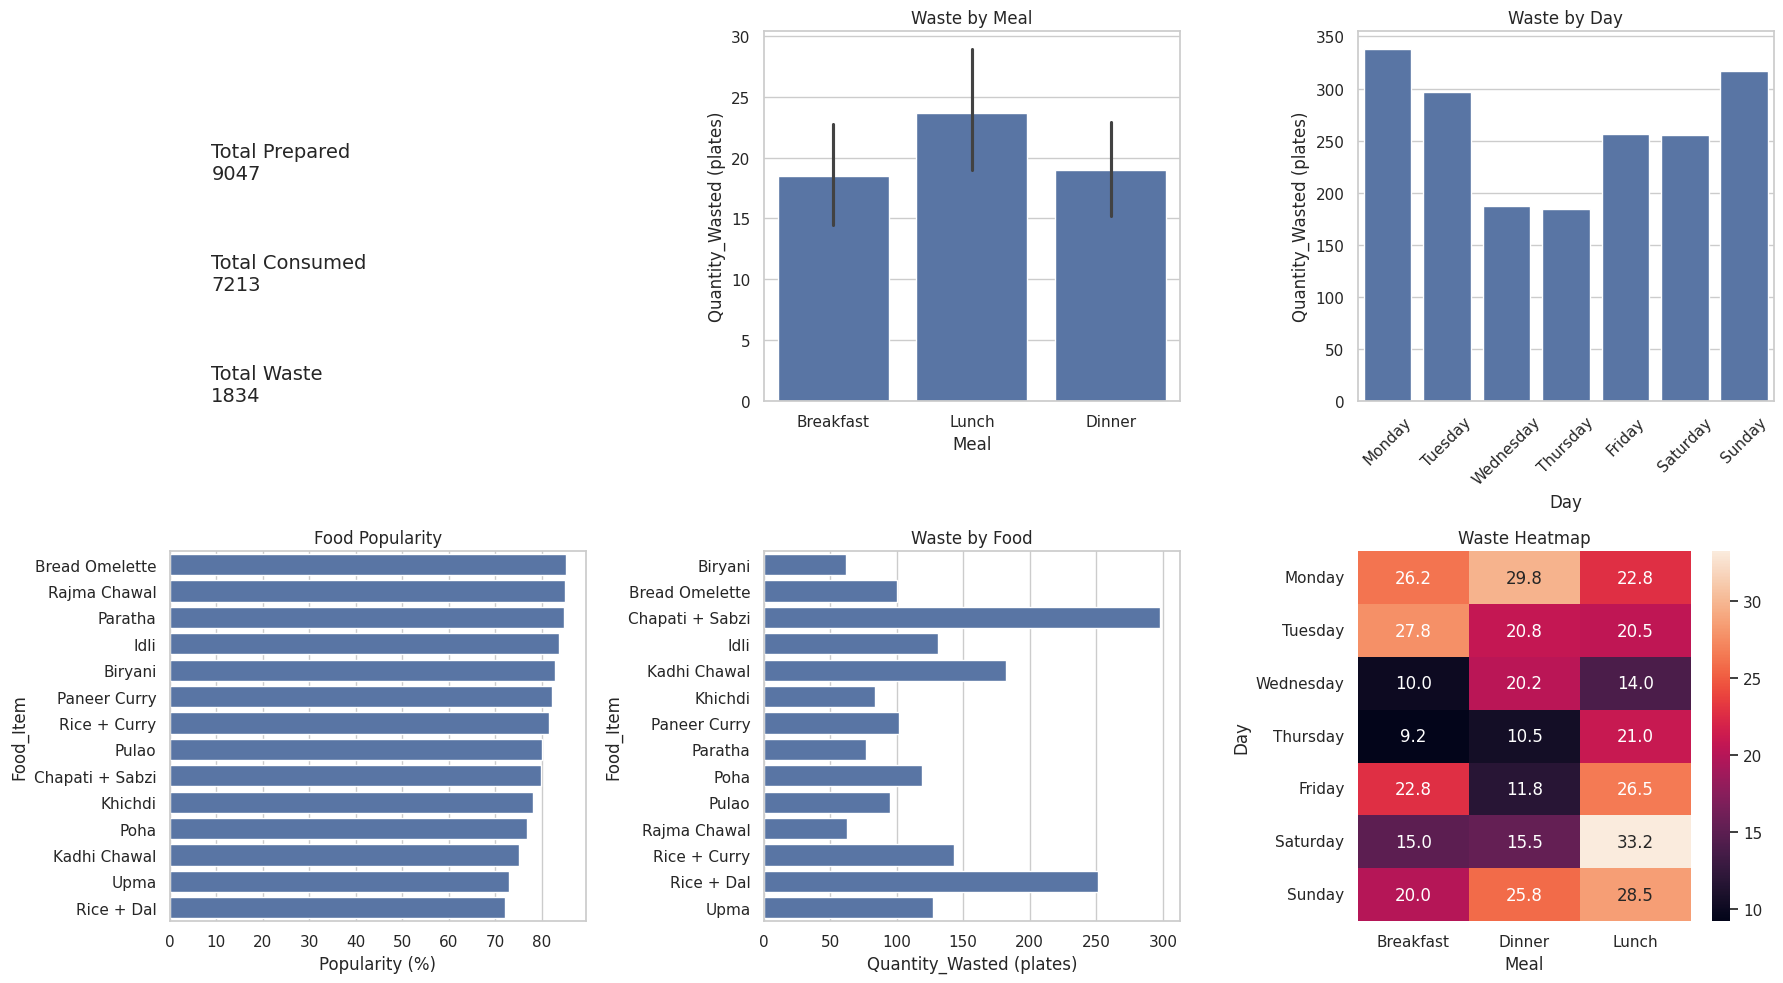

In [3]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("/content/sample_data/hostel_mess_food_data 1.csv")

# Check if 'Date' column exists. If not, use 'Days' column if it exists.
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    # Features
    df['Week'] = df['Date'].dt.isocalendar().week
    df['Day'] = df['Date'].dt.day_name()
    print("Using 'Date' column for date-related features.")
elif 'Days' in df.columns:
    # The 'Days' column contains day names like 'Sunday', 'Monday'.
    # It cannot be directly converted to a datetime object to extract week number.
    # We will use it directly for the 'Day' feature.
    df['Day'] = df['Days'] # Assign 'Days' column directly to 'Day'
    df['Week'] = 0 # Placeholder for Week since actual week cannot be determined without a proper date
    print("Warning: 'Date' column not found. Using 'Days' column for day names.")
    print("Week numbers cannot be accurately determined without a proper date column.")
    print("A placeholder value of 0 is used for 'Week'.")
else:
    print("Error: Neither 'Date' nor 'Days' column found in the DataFrame. Cannot proceed with date-related features.")
    # Create dummy columns to avoid further errors in subsequent steps
    df['Week'] = 0
    df['Day'] = 'Unknown'

# Order days properly, this part is still valid as it operates on df['Day']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
if 'Day' in df.columns: # Ensure 'Day' column was created or exists
    df['Day'] = pd.Categorical(df['Day'], categories=day_order, ordered=True)

# Metrics
# This line depends on 'Quantity_Consumed (plates)' and 'Quantity_Prepared (plates)' which seem to exist.
if 'Quantity_Consumed (plates)' in df.columns and 'Quantity_Prepared (plates)' in df.columns:
    df['Consumption_Rate'] = df['Quantity_Consumed (plates)'] / df['Quantity_Prepared (plates)']
else:
    print("Warning: 'Quantity_Consumed (plates)' or 'Quantity_Prepared (plates)' not found. 'Consumption_Rate' not calculated.")
    df['Consumption_Rate'] = 0 # Placeholder


# ===============================
# 3. KPI VALUES
# ===============================
# Add checks for column existence before summing to prevent errors if df was malformed
total_prepared = df['Quantity_Prepared (plates)'].sum() if 'Quantity_Prepared (plates)' in df.columns else 0
total_consumed = df['Quantity_Consumed (plates)'].sum() if 'Quantity_Consumed (plates)' in df.columns else 0
total_waste = df['Quantity_Wasted (plates)'].sum() if 'Quantity_Wasted (plates)' in df.columns else 0


# ===============================
# 4. CREATE DASHBOARD
# ===============================
plt.figure(figsize=(18,10))


# -------------------------------
# KPI PANEL
# -------------------------------
plt.subplot(2,3,1)
plt.axis('off')
plt.text(0.1, 0.6, f"Total Prepared\n{total_prepared}", fontsize=14)
plt.text(0.1, 0.3, f"Total Consumed\n{total_consumed}", fontsize=14)
plt.text(0.1, 0.0, f"Total Waste\n{total_waste}", fontsize=14)


# -------------------------------
# MEAL-WISE WASTE
# -------------------------------
plt.subplot(2,3,2)
# Check for 'Meal' and 'Quantity_Wasted (plates)' before plotting
if 'Meal' in df.columns and 'Quantity_Wasted (plates)' in df.columns:
    sns.barplot(data=df, x='Meal', y='Quantity_Wasted (plates)')
    plt.title("Waste by Meal")
else:
    plt.text(0.5, 0.5, "Data for Meal-wise Waste not available", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


# -------------------------------
# DAY-WISE WASTE
# -------------------------------
plt.subplot(2,3,3)
# Check for 'Day' and 'Quantity_Wasted (plates)' before grouping and plotting
if 'Day' in df.columns and 'Quantity_Wasted (plates)' in df.columns:
    day_waste = df.groupby('Day')['Quantity_Wasted (plates)'].sum().reset_index()
    sns.barplot(data=day_waste, x='Day', y='Quantity_Wasted (plates)')
    plt.title("Waste by Day")
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, "Data for Day-wise Waste not available", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


# -------------------------------
# FOOD POPULARITY
# -------------------------------
plt.subplot(2,3,4)
# Check for necessary columns before grouping and plotting
if all(col in df.columns for col in ['Food_Item', 'Quantity_Prepared (plates)', 'Quantity_Consumed (plates)']):
    food = df.groupby('Food_Item').agg({
        'Quantity_Prepared (plates)': 'sum',
        'Quantity_Consumed (plates)': 'sum'
    }).reset_index()

    food['Popularity (%)'] = (food['Quantity_Consumed (plates)'] / food['Quantity_Prepared (plates)']) * 100
    food = food.sort_values(by='Popularity (%)', ascending=False)

    sns.barplot(data=food, x='Popularity (%)', y='Food_Item')
    plt.title("Food Popularity")
else:
    plt.text(0.5, 0.5, "Data for Food Popularity not available", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


# -------------------------------
# WASTE BY FOOD
# -------------------------------
plt.subplot(2,3,5)
# Check for necessary columns before grouping and plotting
if 'Food_Item' in df.columns and 'Quantity_Wasted (plates)' in df.columns:
    waste_food = df.groupby('Food_Item')['Quantity_Wasted (plates)'].sum().reset_index()
    sns.barplot(data=waste_food, x='Quantity_Wasted (plates)', y='Food_Item')
    plt.title("Waste by Food")
else:
    plt.text(0.5, 0.5, "Data for Waste by Food not available", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


# -------------------------------
# HEATMAP (DAY vs MEAL)
# -------------------------------
plt.subplot(2,3,6)
# Check for necessary columns before pivoting and plotting
if all(col in df.columns for col in ['Day', 'Meal', 'Quantity_Wasted (plates)']):
    pivot = df.pivot_table(values='Quantity_Wasted (plates)',
                           index='Day',
                           columns='Meal',
                           aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt=".1f")
    plt.title("Waste Heatmap")
else:
    plt.text(0.5, 0.5, "Data for Waste Heatmap not available", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


# ===============================
# SHOW DASHBOARD
# ===============================
plt.tight_layout()
plt.show()